 # ResearchLens LK — OpenAlex vs Crossref Metadata Enrichment Analysis (v4)




 ## 1. Imports & display settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)


 ## 2. Load data

In [2]:
OA_PATH = "../data/raw/open-alex/open-alex.csv"
CR_PATH = "../data/processed/crossref_clean_2016_2026.csv"

oa = pd.read_csv(OA_PATH, low_memory=False)
cr = pd.read_csv(CR_PATH, low_memory=False)

print("OpenAlex (raw):", oa.shape)
print("Crossref:", cr.shape)

oa = oa[oa["publication_year"] >= 2016].copy()
print("OpenAlex (2016+):", oa.shape)


OpenAlex (raw): (59942, 44)
Crossref: (26933, 55)
OpenAlex (2016+): (41407, 44)


In [49]:
oa.columns
cr.columns

Index(['reference-count', 'publisher', 'issue', 'abstract', 'DOI', 'type', 'is-referenced-by-count', 'title', 'volume', 'container-title', 'URL',
       'ISSN', 'issued.date-parts', 'published.date-parts', 'created.date-parts', 'page', 'event.name', 'event.location', 'event.start.date-parts',
       'event.end.date-parts', 'language', 'article-number', 'publisher-location', 'event.acronym', 'group-title', 'subtype', 'event.sponsor',
       'original-title', 'subtitle', 'publication_year', 'author_given', 'author_family', 'author_name', 'author_affiliation', 'author_ORCID',
       'author_authenticated-orcid', 'author_sequence', 'author_role', 'editor_given', 'editor_family', 'editor_name', 'editor_affiliation',
       'editor_ORCID', 'editor_authenticated-orcid', 'editor_sequence', 'editor_role', 'funder_name', 'funder_DOI', 'funder_id', 'funder_award',
       'funder_doi-asserted-by', 'license_URL', 'license_content-version', 'license_delay-in-days', 'references_json', 'doi_norm'],
  

 ## 3. Missing-value & coverage helpers



In [4]:
MISSING_TOKENS = {"", "nan", "null", "none", "[]", "{}"}


def is_missing(v):
    """True for real NaN and for stringified placeholders CSV exports use
    for empty lists/dicts ("nan", "[]", "{}", etc.). Does NOT treat boolean
    False as missing — see note above."""
    if pd.isna(v):
        return True
    return str(v).strip().lower() in MISSING_TOKENS


def coverage(df, column):
    """% of non-missing values for `column` in `df`. NaN if column/frame is empty."""
    if column is None or column not in df.columns or len(df) == 0:
        return np.nan
    present = df[column].apply(lambda x: not is_missing(x)).sum()
    return round((present / len(df)) * 100, 2)



 ## 4. Derived columns



 OpenAlex splits page numbers into `first_page`/`last_page`; Crossref uses

 a single `page` field ("123-145"). Build one presence flag on the

 OpenAlex side so the two compare like-for-like later.



 Stores True/NaN, not True/False — see the note in Section 3.

In [5]:
page_present = ~(oa["first_page"].apply(is_missing) & oa["last_page"].apply(is_missing))
oa["has_page_info"] = np.where(page_present, True, np.nan)


 ## 5. Field map




In [6]:
FIELD_MAP = {
    "oa_doi": "doi",
    "cr_doi": "DOI",
    "oa_abstract": None,  # OpenAlex export has no abstract field
    "cr_abstract": "abstract",
    "oa_orcid": None,  # OpenAlex export has no ORCID field
    "cr_orcid": "author_ORCID_any",  # created during Crossref aggregation, Section 9
    "oa_license": None,  # OpenAlex export has no license field
    "cr_license": "license_URL",
    "oa_article_number": None,  # OpenAlex export has no article-number field
    "cr_article_number": "article-number",
    "oa_container": "source_name",
    "cr_container": "container-title",
    "oa_issn": "journal_issn_l",
    "cr_issn": "ISSN",
    "oa_funder": "funders",
    "cr_funder": "funder_name_any",  # created during Crossref aggregation, Section 9
    "oa_reference": "referenced_works_count",
    "cr_reference": "reference-count",
    "oa_cited_by": "cited_by_count",
    "cr_cited_by": "is-referenced-by-count",
}
FIELD_MAP


{'oa_doi': 'doi',
 'cr_doi': 'DOI',
 'oa_abstract': None,
 'cr_abstract': 'abstract',
 'oa_orcid': None,
 'cr_orcid': 'author_ORCID_any',
 'oa_license': None,
 'cr_license': 'license_URL',
 'oa_article_number': None,
 'cr_article_number': 'article-number',
 'oa_container': 'source_name',
 'cr_container': 'container-title',
 'oa_issn': 'journal_issn_l',
 'cr_issn': 'ISSN',
 'oa_funder': 'funders',
 'cr_funder': 'funder_name_any',
 'oa_reference': 'referenced_works_count',
 'cr_reference': 'reference-count',
 'oa_cited_by': 'cited_by_count',
 'cr_cited_by': 'is-referenced-by-count'}

 ### Sanity check (optional)



In [7]:
def find_cols(df, keyword):
    return [c for c in df.columns if keyword.lower() in c.lower()]


for kw in [
    "doi",
    "abstract",
    "fund",
    "orcid",
    "license",
    "reference",
    "article",
    "issn",
    "volume",
    "issue",
    "container",
    "source",
    "event",
    "publisher",
    "cited",
    "referenced-by",
    "type",
]:
    print(f"{kw:10s} -> OA: {find_cols(oa, kw)}  |  CR: {find_cols(cr, kw)}")


doi        -> OA: ['doi']  |  CR: ['DOI', 'funder_DOI', 'funder_doi-asserted-by']
abstract   -> OA: []  |  CR: ['abstract']
fund       -> OA: ['funders']  |  CR: ['funder_name', 'funder_DOI', 'funder_id', 'funder_award', 'funder_doi-asserted-by']
orcid      -> OA: []  |  CR: ['author_ORCID', 'author_authenticated-orcid', 'editor_ORCID', 'editor_authenticated-orcid']
license    -> OA: []  |  CR: ['license_URL', 'license_content-version', 'license_delay-in-days']
reference  -> OA: ['referenced_works_count']  |  CR: ['reference-count', 'is-referenced-by-count', 'references_json']
article    -> OA: []  |  CR: ['article-number']
issn       -> OA: ['journal_issn_l']  |  CR: ['ISSN']
volume     -> OA: ['volume']  |  CR: ['volume']
issue      -> OA: ['issue']  |  CR: ['issue', 'issued.date-parts']
container  -> OA: []  |  CR: ['container-title']
source     -> OA: ['source_id', 'source_name', 'source_type']  |  CR: []
event      -> OA: []  |  CR: ['event.name', 'event.location', 'event.start.da

 ## 6. Normalize DOIs

In [8]:
def normalize_doi(x):
    if pd.isna(x):
        return None
    x = str(x).strip().lower()
    x = x.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return x


oa["doi_norm"] = oa[FIELD_MAP["oa_doi"]].apply(normalize_doi)
cr["doi_norm"] = cr[FIELD_MAP["cr_doi"]].apply(normalize_doi)

doi_stats = pd.DataFrame(
    {
        "Dataset": ["OpenAlex", "Crossref"],
        "Unique DOI": [oa["doi_norm"].nunique(), cr["doi_norm"].nunique()],
        "Missing DOI": [oa["doi_norm"].isna().sum(), cr["doi_norm"].isna().sum()],
    }
)
doi_stats


,Dataset,Unique DOI,Missing DOI
0,OpenAlex,40003,1395
1,Crossref,26719,0


 ## 7. DOI overlap + export the missing DOIs



In [9]:
oa_dois = set(oa["doi_norm"].dropna())
cr_dois = set(cr["doi_norm"].dropna())

common = oa_dois & cr_dois
oa_only = oa_dois - cr_dois
cr_only = cr_dois - oa_dois

print(f"Common DOIs:          {len(common):,}")
print(f"OpenAlex only:        {len(oa_only):,}")
print(f"Crossref only:        {len(cr_only):,}")
print(f"Overlap rate (of OA): {len(common) / len(oa_dois) * 100:.1f}%")


Common DOIs:          26,668
OpenAlex only:        13,335
Crossref only:        51
Overlap rate (of OA): 66.7%


In [10]:
oa_only_df = (
    oa[oa["doi_norm"].isin(oa_only)][["doi_norm", "title", "type", "publication_year"]]
    .drop_duplicates(subset="doi_norm")
    .copy()
)

EXPORT_PATH = "../data/processed/oa_only_dois_for_crossref_refetch.csv"
oa_only_df.to_csv(EXPORT_PATH, index=False)
print(f"Exported {len(oa_only_df):,} DOIs to {EXPORT_PATH}")


Exported 13,335 DOIs to ../data/processed/oa_only_dois_for_crossref_refetch.csv


 ## 8. Collapse Crossref to one row per DOI



In [11]:
oa_dup_count = oa["doi_norm"].duplicated().sum()
cr_dup_count = cr["doi_norm"].duplicated().sum()
print("OpenAlex duplicate DOI rows:", oa_dup_count)
print(
    "Crossref duplicate DOI rows:",
    cr_dup_count,
    f"({cr.shape[0]:,} raw rows -> {cr['doi_norm'].nunique():,} unique DOIs)",
)



OpenAlex duplicate DOI rows: 1403
Crossref duplicate DOI rows: 214 (26,933 raw rows -> 26,719 unique DOIs)


In [12]:
def clean_missing_tokens(df):
    """Replace all missing-token placeholders with real NaN across the whole
    frame, once, so groupby aggregations can use pandas' fast built-in
    first()/notna() instead of a slow per-group Python lambda."""
    cleaned = df.copy()
    for col in cleaned.columns:
        cleaned[col] = cleaned[col].where(~cleaned[col].apply(is_missing), np.nan)
    return cleaned


def aggregate_crossref(df, doi_col="doi_norm"):
    """Collapse a Crossref frame with possibly multiple rows per DOI into one
    row per DOI. Scalar/bibliographic columns take the first non-missing
    value; author_*/editor_*/funder_* columns become `{col}_any` (True if any
    row for this DOI was non-missing for that column, else NaN) plus a
    `row_count` column."""
    person_prefixes = ("author_", "editor_", "funder_")
    person_cols = [c for c in df.columns if c.startswith(person_prefixes)]
    scalar_cols = [c for c in df.columns if c not in person_cols and c != doi_col]

    g = df.groupby(doi_col)

    scalar_agg = g[scalar_cols].first()
    scalar_agg["row_count"] = g.size()

    person_summary = pd.DataFrame(index=scalar_agg.index)
    for col in person_cols:
        person_summary[f"{col}_any"] = g[col].apply(
            lambda s: True if s.notna().any() else np.nan
        )

    return scalar_agg.join(person_summary).reset_index()


cr_clean = clean_missing_tokens(cr)
cr_agg_all = aggregate_crossref(cr_clean, doi_col="doi_norm")

print("Crossref aggregated:", cr_agg_all.shape, "(one row per DOI)")
print("\nRaw rows collapsed per DOI (1 = no duplication):")
print(cr_agg_all["row_count"].value_counts().sort_index().head(10))


Crossref aggregated: (26719, 57) (one row per DOI)

Raw rows collapsed per DOI (1 = no duplication):
row_count
1    26667
4        5
5       36
6       11
Name: count, dtype: int64


 ## 9. Build the common-DOI merged dataset


In [13]:
oa_common = oa[oa["doi_norm"].isin(common)].drop_duplicates(subset="doi_norm").copy()
cr_common_agg = cr_agg_all[cr_agg_all["doi_norm"].isin(common)].copy()

merged = oa_common.merge(cr_common_agg, on="doi_norm", suffixes=("_oa", "_cr"))

print("Merged shape:", merged.shape, "| expected rows:", len(common))
assert len(merged) == len(common), (
    "Merge produced an unexpected row count — check for remaining duplicates"
)


Merged shape: (26668, 102) | expected rows: 26668


 ## 10. Column-resolution helpers




In [14]:
def resolve_merged_col(base_col, suffix):
    if base_col is None:
        return None
    if base_col + suffix in merged.columns:
        return base_col + suffix
    if base_col in merged.columns:
        return base_col
    return None


def overlap_table(oa_col_base, cr_col_base, label):
    """OA-only / CR-only / Both / Neither breakdown for a field pair, on `merged`."""
    oa_col = resolve_merged_col(oa_col_base, "_oa")
    cr_col = resolve_merged_col(cr_col_base, "_cr")
    if not oa_col or not cr_col:
        print(
            f"[{label}] column not found -> oa:{oa_col_base} cr:{cr_col_base} (skipped)"
        )
        return None

    oa_present = ~merged[oa_col].apply(is_missing)
    cr_present = ~merged[cr_col].apply(is_missing)

    table = pd.DataFrame(
        {
            "Category": ["OA only", "CR only (recoverable)", "Both", "Neither"],
            "Count": [
                int((oa_present & ~cr_present).sum()),
                int((~oa_present & cr_present).sum()),
                int((oa_present & cr_present).sum()),
                int((~oa_present & ~cr_present).sum()),
            ],
        }
    )
    table["% of common DOIs"] = round(table["Count"] / len(merged) * 100, 2)
    table.insert(0, "Field", label)
    return table


def field_report(df, col, label, scope_label):
    """Standalone coverage report for a field that only exists on one side."""
    if col is None or col not in df.columns:
        print(f"[{label}] column not found: {col}")
        return None
    present = int((~df[col].apply(is_missing)).sum())
    return {
        "Field": label,
        "Scope": scope_label,
        "Coverage %": coverage(df, col),
        "Records with data": present,
        "Total records": len(df),
    }



 ## 11. Type distribution & mapping

In [15]:
print("OpenAlex types:")
print(oa["type"].value_counts())

print("\nCrossref types:")
print(cr["type"].value_counts())


OpenAlex types:
type
article                34235
book-chapter            2302
preprint                1582
review                  1205
report                   850
dataset                  345
conference-paper         198
peer-review              147
other                    134
letter                   106
book                      85
editorial                 59
software                  40
reference-entry           38
erratum                   30
paratext                  19
dissertation              18
conference-abstract       10
retraction                 4
Name: count, dtype: int64

Crossref types:
type
journal-article        20223
proceedings-article     2958
book-chapter            2282
posted-content          1081
peer-review              146
other                     75
reference-entry           42
dataset                   39
book                      34
monograph                 20
edited-book               14
journal-issue             12
report                     6
ref

In [16]:
TYPE_MAP = {
    # journal articles
    "article": "journal-article",  # OpenAlex
    "journal-article": "journal-article",  # Crossref
    # conference papers — OA and CR use different vocab, both map here
    "conference-paper": "conference-paper",  # OpenAlex
    "proceedings-article": "conference-paper",  # Crossref
    "conference-abstract": "conference-paper",
    # books
    "book-chapter": "book-chapter",
    "book": "book",
    "reference-book": "book",
    "monograph": "book",
    "edited-book": "book-chapter",
    # preprints
    "preprint": "preprint",
    "posted-content": "preprint",  # Crossref's preprint label
    # everything else — identity mapping, kept explicit rather than falling
    # through to NaN and silently dropping out of type-based analysis
    "review": "review",
    "peer-review": "peer-review",
    "report": "report",
    "dataset": "dataset",
    "letter": "letter",
    "editorial": "editorial",
    "software": "software",
    "reference-entry": "reference-entry",
    "erratum": "erratum",
    "paratext": "paratext",
    "dissertation": "dissertation",
    "retraction": "retraction",
    "other": "other",
    "journal-issue": "journal-issue",  # Crossref: a whole issue, not an article
}

oa["type_group"] = oa["type"].map(TYPE_MAP)
cr_agg_all["type_group"] = cr_agg_all["type"].map(TYPE_MAP)

unmapped_oa = oa.loc[oa["type_group"].isna() & oa["type"].notna(), "type"].unique()
unmapped_cr = cr_agg_all.loc[
    cr_agg_all["type_group"].isna() & cr_agg_all["type"].notna(), "type"
].unique()
if len(unmapped_oa) or len(unmapped_cr):
    print("Unmapped type values (add to TYPE_MAP if these matter):")
    print("  OA:", list(unmapped_oa))
    print("  CR:", list(unmapped_cr))


 ## 12. Journal metadata completeness (OA vs CR)




In [17]:
journal_field_candidates = {
    "volume": ("volume", "volume"),
    "issue": ("issue", "issue"),
    "page": ("has_page_info", "page"),
    "journal/container name": (FIELD_MAP["oa_container"], FIELD_MAP["cr_container"]),
    "ISSN": (FIELD_MAP["oa_issn"], FIELD_MAP["cr_issn"]),
}

journal_oa = oa[oa["type_group"] == "journal-article"]
journal_cr = cr_agg_all[cr_agg_all["type_group"] == "journal-article"]

rows = []
for label, (oa_col, cr_col) in journal_field_candidates.items():
    rows.append(
        {
            "field": label,
            "oa_coverage_%": coverage(journal_oa, oa_col),
            "cr_coverage_%": coverage(journal_cr, cr_col),
        }
    )

journal_comparison = pd.DataFrame(rows)
journal_comparison


,field,oa_coverage_%,cr_coverage_%
0,volume,71.84,93.20
1,issue,58.60,81.68
2,page,80.85,77.02
3,journal/container name,79.02,100.00
4,ISSN,72.92,99.72


 ## 13. Conference metadata completeness (OA vs CR)




In [18]:
conference_field_candidates = {
    "event name": (None, "event.name"),
    "publisher": ("publisher", "publisher"),
}

conference_oa = oa[oa["type_group"] == "conference-paper"]
conference_cr = cr_agg_all[cr_agg_all["type_group"] == "conference-paper"]

print(
    f"OA conference-paper rows: {len(conference_oa):,} | CR conference-paper rows: {len(conference_cr):,}"
)

rows = []
for label, (oa_col, cr_col) in conference_field_candidates.items():
    rows.append(
        {
            "field": label,
            "oa_coverage_%": coverage(conference_oa, oa_col),
            "cr_coverage_%": coverage(conference_cr, cr_col),
        }
    )

conference_comparison = pd.DataFrame(rows)
conference_comparison


OA conference-paper rows: 208 | CR conference-paper rows: 2,958


,field,oa_coverage_%,cr_coverage_%
0,event name,NaN,100.0
1,publisher,94.71,100.0


 ## 14. Crossref-exclusive fields: abstract, ORCID, license, article number



 

In [19]:
exclusive_fields = [
    ("abstract", FIELD_MAP["cr_abstract"]),
    ("ORCID (any author)", FIELD_MAP["cr_orcid"]),
    ("license", FIELD_MAP["cr_license"]),
    ("article number", FIELD_MAP["cr_article_number"]),
]

rows = []
for label, col in exclusive_fields:
    rows.append(field_report(cr_agg_all, col, label, "All Crossref DOIs"))
    cr_col_in_merged = resolve_merged_col(col, "_cr")
    rows.append(field_report(merged, cr_col_in_merged, label, "Common DOIs only"))

cr_exclusive_df = pd.DataFrame([r for r in rows if r])
cr_exclusive_df


,Field,Scope,Coverage %,Records with data,Total records
0,abstract,All Crossref DOIs,40.54,10832,26719
1,abstract,Common DOIs only,40.58,10823,26668
2,ORCID (any author),All Crossref DOIs,23.58,6300,26719
3,ORCID (any author),Common DOIs only,23.59,6290,26668
4,license,All Crossref DOIs,48.56,12974,26719
5,license,Common DOIs only,48.50,12934,26668
6,article number,All Crossref DOIs,10.58,2828,26719
7,article number,Common DOIs only,10.58,2821,26668


 ## 15. ISSN — is it actually a print/electronic pair?




In [20]:
issn_col = resolve_merged_col(FIELD_MAP["cr_issn"], "_cr")
sample_issn_values = merged[issn_col].dropna().head(15).tolist()
for v in sample_issn_values:
    print(v)


['1364-0321']
['0013-9351']
['2405-8440']
['2772-3976']
['1044-579X']
['0020-0255']
['2210-6014']
['0022-3697']
['2214-5095']
['2579-2075', '1800-3036']
['1756-0500']
['1178-2021']
['2199-8531']
['2345-9913']
['1472-6882']


 ## 16. Funder metadata — overlap on common DOIs




In [21]:
funder_overlap = overlap_table(FIELD_MAP["oa_funder"], FIELD_MAP["cr_funder"], "funder")
funder_overlap


,Field,Category,Count,% of common DOIs
0,funder,OA only,1570,5.89
1,funder,CR only (recoverable),219,0.82
2,funder,Both,1281,4.80
3,funder,Neither,23598,88.49


 ## 17. Reference-count coverage (magnitude, not presence)




In [22]:
oa_ref_col = resolve_merged_col(FIELD_MAP["oa_reference"], "_oa")
cr_ref_col = resolve_merged_col(FIELD_MAP["cr_reference"], "_cr")

ref_summary = pd.DataFrame(
    {
        "OpenAlex": merged[oa_ref_col].describe(),
        "Crossref": merged[cr_ref_col].describe(),
    }
)
print(ref_summary)

print("\n% of records with reference count == 0")
print("OpenAlex:", round((merged[oa_ref_col] == 0).mean() * 100, 2), "%")
print("Crossref:", round((merged[cr_ref_col] == 0).mean() * 100, 2), "%")


           OpenAlex      Crossref
count  26668.000000  26668.000000
mean      17.187266     15.275686
std       29.781874     35.641366
min        0.000000      0.000000
25%        0.000000      0.000000
50%        9.000000      0.000000
75%       24.000000     22.000000
max     2545.000000   3671.000000

% of records with reference count == 0
OpenAlex: 36.34 %
Crossref: 58.1 %


 ## 18. Citation-count divergence (BiasNote signal)




In [23]:
oa_cite_col = resolve_merged_col(FIELD_MAP["oa_cited_by"], "_oa")
cr_cite_col = resolve_merged_col(FIELD_MAP["cr_cited_by"], "_cr")

cite_df = merged[["doi_norm", oa_cite_col, cr_cite_col]].copy()
cite_df.columns = ["doi_norm", "oa_cited_by", "cr_referenced_by"]

cite_df["diff"] = cite_df["cr_referenced_by"] - cite_df["oa_cited_by"]
cite_df["abs_diff"] = cite_df["diff"].abs()
cite_df["ratio"] = np.where(
    cite_df["oa_cited_by"] > 0,
    cite_df["cr_referenced_by"] / cite_df["oa_cited_by"],
    np.nan,
)

print(cite_df[["oa_cited_by", "cr_referenced_by", "diff"]].describe())

SIGNIFICANT_ABS_DIFF = 10
SIGNIFICANT_RATIO = 1.5

cite_df["diverges"] = (cite_df["abs_diff"] >= SIGNIFICANT_ABS_DIFF) & (
    (cite_df["ratio"] >= SIGNIFICANT_RATIO)
    | (cite_df["ratio"] <= 1 / SIGNIFICANT_RATIO)
)

print(
    f"\nRecords with significant citation-count divergence: "
    f"{cite_df['diverges'].sum():,} ({cite_df['diverges'].mean() * 100:.1f}%)"
)

cite_df.sort_values("abs_diff", ascending=False).head(10)


        oa_cited_by  cr_referenced_by          diff
count  26668.000000      26668.000000  26668.000000
mean       4.870819          3.744938     -1.125881
std       23.157028         19.518172      5.477549
min        0.000000          0.000000   -347.000000
25%        0.000000          0.000000     -1.000000
50%        1.000000          0.000000      0.000000
75%        4.000000          3.000000      0.000000
max     2043.000000       1893.000000     71.000000

Records with significant citation-count divergence: 337 (1.3%)


,doi_norm,oa_cited_by,cr_referenced_by,diff,abs_diff,ratio,diverges
13,10.4038/sljer.v7i2.119,348,1,-347,347,0.002874,True
1,10.1016/j.envres.2020.109819,1326,994,-332,332,0.749623,False
8,10.1016/j.cscm.2022.e01059,470,232,-238,238,0.493617,True
9,10.4038/sljhrm.v5i1.5624,434,223,-211,211,0.513825,True
3,10.1016/j.clema.2024.100220,872,676,-196,196,0.775229,False
30,10.1007/978-94-007-6172-8_142-1,167,0,-167,167,0.000000,True
10,10.1186/s13104-016-1962-1,386,223,-163,163,0.577720,True
4,10.1016/j.semcancer.2019.05.012,781,626,-155,155,0.801536,False
0,10.1016/j.rser.2016.05.022,2043,1893,-150,150,0.926579,False
12,10.3390/joitmc5040100,354,236,-118,118,0.666667,True


 ## 19. Sri Lanka subset validation




In [24]:
print(
    oa["sri_lankan_authors"].dtype,
    "\n",
    oa["sri_lankan_authors"].value_counts(dropna=False).head(),
)
print(
    oa["sri_lankan_institutions"].dtype,
    "\n",
    oa["sri_lankan_institutions"].value_counts(dropna=False).head(),
)



str 
 sri_lankan_authors
LUNCHANAWAT NIMMAHNRATANAKUL      397
NIMMAHNRATANAKUL, LUNCHANAWAT     143
Candauda Arachchige Saliya        110
Rishmi Ayodhya Sri Wijebandara     60
Aditi Mukherji                     52
Name: count, dtype: int64
str 
 sri_lankan_institutions
University of Moratuwa                           3975
University of Peradeniya                         3330
University of Sri Jayewardenepura                3279
University of Colombo                            3199
Sri Lanka Institute of Information Technology    2523
Name: count, dtype: int64


In [25]:
def is_sl_tagged(df):
    """True where sri_lankan_authors or sri_lankan_institutions indicates
    the record is SL-tagged. Boolean columns are checked for True
    specifically (False must NOT count as "tagged"); non-boolean
    (string/list-encoded) columns fall back to a non-missing check."""
    mask = pd.Series(False, index=df.index)
    for col in ["sri_lankan_authors", "sri_lankan_institutions"]:
        if col not in df.columns:
            continue
        series = df[col]
        non_null_values = set(series.dropna().unique().tolist())
        looks_boolean = series.dtype == bool or non_null_values <= {
            True,
            False,
            "True",
            "False",
        }
        if looks_boolean:
            mask = mask | series.fillna(False).astype(str).isin(["True", "1"])
        else:
            mask = mask | (~series.apply(is_missing))
    return mask


sl_mask = is_sl_tagged(merged)
sl_subset = merged[sl_mask].copy()
print(
    f"\nSri Lanka-tagged common-DOI records: {len(sl_subset):,} of {len(merged):,} "
    f"({len(sl_subset) / len(merged) * 100:.1f}%)"
)



Sri Lanka-tagged common-DOI records: 26,668 of 26,668 (100.0%)


In [26]:
sl_fields = [
    ("abstract", resolve_merged_col(FIELD_MAP["cr_abstract"], "_cr")),
    ("ORCID (any author)", resolve_merged_col(FIELD_MAP["cr_orcid"], "_cr")),
    ("license", resolve_merged_col(FIELD_MAP["cr_license"], "_cr")),
    ("article number", resolve_merged_col(FIELD_MAP["cr_article_number"], "_cr")),
    ("ISSN", resolve_merged_col(FIELD_MAP["cr_issn"], "_cr")),
]

sl_rows = [
    field_report(sl_subset, col, label, "Sri Lanka-tagged common DOIs")
    for label, col in sl_fields
]
sl_coverage_df = pd.DataFrame([r for r in sl_rows if r])
sl_coverage_df


,Field,Scope,Coverage %,Records with data,Total records
0,abstract,Sri Lanka-tagged common DOIs,40.58,10823,26668
1,ORCID (any author),Sri Lanka-tagged common DOIs,23.59,6290,26668
2,license,Sri Lanka-tagged common DOIs,48.50,12934,26668
3,article number,Sri Lanka-tagged common DOIs,10.58,2821,26668
4,ISSN,Sri Lanka-tagged common DOIs,79.99,21332,26668


In [27]:
sl_doi_set = set(sl_subset["doi_norm"])
sl_cite_divergence_rate = (
    cite_df[cite_df["doi_norm"].isin(sl_doi_set)]["diverges"].mean() * 100
)
print(
    f"Citation-count divergence rate, Sri Lanka subset: {sl_cite_divergence_rate:.1f}%"
)


Citation-count divergence rate, Sri Lanka subset: 1.3%


In [28]:
abstract_col = resolve_merged_col(FIELD_MAP["cr_abstract"], "_cr")
license_col = resolve_merged_col(FIELD_MAP["cr_license"], "_cr")

sample_n = min(50, len(sl_subset))
sl_sample = sl_subset.sample(sample_n, random_state=42)[
    ["doi_norm", abstract_col, license_col]
]

SL_SAMPLE_PATH = "../data/processed/sl_sample_50_for_manual_check.csv"
sl_sample.to_csv(SL_SAMPLE_PATH, index=False)
print(
    f"Saved {sample_n}-record Sri Lanka sample to {SL_SAMPLE_PATH} for manual inspection."
)


Saved 50-record Sri Lanka sample to ../data/processed/sl_sample_50_for_manual_check.csv for manual inspection.


 ## 20. Enrichment matrix — the table for your schema decision




In [29]:
enrichment_rows = []

paired_fields = {
    "volume": ("volume", "volume"),
    "issue": ("issue", "issue"),
    "page": ("has_page_info", "page"),
    "journal/container name": (FIELD_MAP["oa_container"], FIELD_MAP["cr_container"]),
    "ISSN": (FIELD_MAP["oa_issn"], FIELD_MAP["cr_issn"]),
    "funder": (FIELD_MAP["oa_funder"], FIELD_MAP["cr_funder"]),
}
for label, (oa_c, cr_c) in paired_fields.items():
    oa_r = resolve_merged_col(oa_c, "_oa")
    cr_r = resolve_merged_col(cr_c, "_cr")
    if not oa_r or not cr_r:
        continue
    oa_missing_mask = merged[oa_r].apply(is_missing)
    cr_present_mask = ~merged[cr_r].apply(is_missing)
    cr_only = int((oa_missing_mask & cr_present_mask).sum())
    enrichment_rows.append(
        {
            "Field": label,
            "OA coverage %": coverage(merged, oa_r),
            "CR coverage %": coverage(merged, cr_r),
            "CR-only records": cr_only,
            "Recommendation": "Keep" if cr_only > 0 else "Optional",
        }
    )

exclusive_fields_map = {
    "abstract": FIELD_MAP["cr_abstract"],
    "ORCID (any author)": FIELD_MAP["cr_orcid"],
    "license": FIELD_MAP["cr_license"],
    "article number": FIELD_MAP["cr_article_number"],
}
for label, cr_c in exclusive_fields_map.items():
    cr_r = resolve_merged_col(cr_c, "_cr")
    if not cr_r:
        continue
    cr_only = int((~merged[cr_r].apply(is_missing)).sum())
    enrichment_rows.append(
        {
            "Field": label,
            "OA coverage %": 0.0,
            "CR coverage %": coverage(merged, cr_r),
            "CR-only records": cr_only,
            "Recommendation": "Keep" if cr_only > 0 else "Optional",
        }
    )

enrichment_matrix = pd.DataFrame(enrichment_rows).sort_values(
    "CR-only records", ascending=False
)
enrichment_matrix


,Field,OA coverage %,CR coverage %,CR-only records,Recommendation
8,license,0.00,48.50,12934,Keep
6,abstract,0.00,40.58,10823,Keep
7,ORCID (any author),0.00,23.59,6290,Keep
3,journal/container name,85.51,95.24,3528,Keep
9,article number,0.00,10.58,2821,Keep
5,funder,10.69,5.62,219,Keep
2,page,81.48,77.13,40,Keep
4,ISSN,81.48,79.99,23,Keep
0,volume,73.12,69.99,11,Keep
1,issue,61.37,61.29,9,Keep


In [30]:
print(
    f"Citation-count divergence: {cite_df['diverges'].sum():,} of {len(cite_df):,} "
    f"common DOIs ({cite_df['diverges'].mean() * 100:.1f}%) — "
    "add oa_cited_by, cr_referenced_by, and a computed divergence flag to the schema."
)


Citation-count divergence: 337 of 26,668 common DOIs (1.3%) — add oa_cited_by, cr_referenced_by, and a computed divergence flag to the schema.


 ## 21. Overall metadata richness

In [31]:
def richness_score(df, sample=20000, random_state=42):
    data = (
        df.sample(sample, random_state=random_state)
        if sample and len(df) > sample
        else df
    )
    counts = data.apply(lambda row: sum(not is_missing(v) for v in row), axis=1)
    return {"Average": round(counts.mean(), 2), "Median": round(counts.median(), 2)}


print("OpenAlex richness:", richness_score(oa))
print("Crossref richness (aggregated):", richness_score(cr_agg_all))


OpenAlex richness: {'Average': np.float64(41.38), 'Median': np.float64(43.0)}
Crossref richness (aggregated): {'Average': np.float64(25.25), 'Median': np.float64(25.0)}


 ## 22. Visualization — coverage comparison

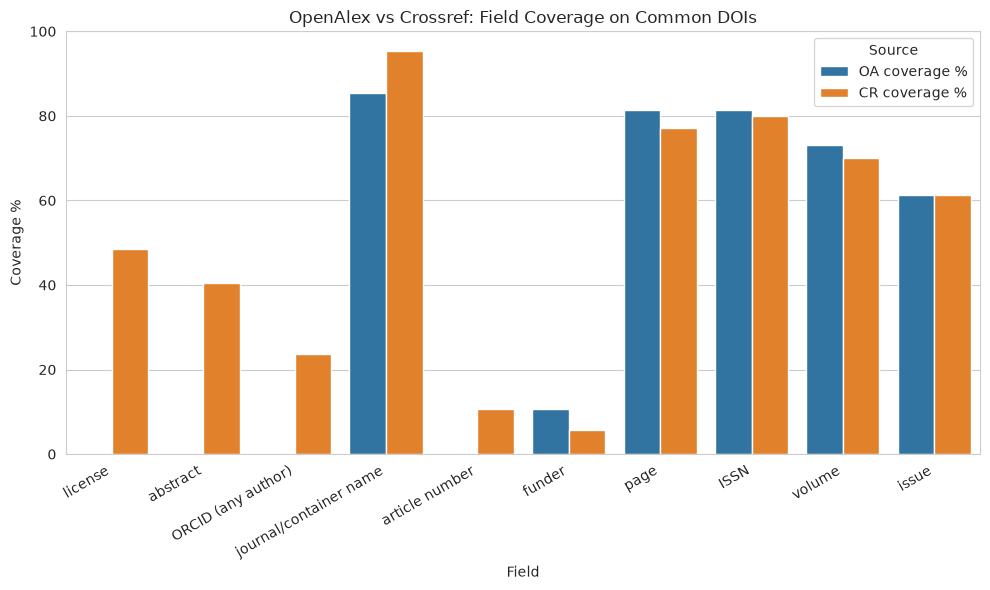

In [32]:
plot_df = enrichment_matrix.melt(
    id_vars="Field",
    value_vars=["OA coverage %", "CR coverage %"],
    var_name="Source",
    value_name="Coverage %",
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="Field", y="Coverage %", hue="Source")
plt.xticks(rotation=30, ha="right")
plt.title("OpenAlex vs Crossref: Field Coverage on Common DOIs")
plt.tight_layout()
plt.show()


In [33]:
ref = merged[["doi_norm", "referenced_works_count", "reference-count"]].copy()

ref["diff"] = ref["reference-count"] - ref["referenced_works_count"]
ref["abs_diff"] = ref["diff"].abs()

print(ref[["referenced_works_count", "reference-count", "diff"]].describe())

print("Exact match %:", (ref["diff"] == 0).mean() * 100)

print(">5 diff %:", (ref["abs_diff"] > 5).mean() * 100)

print(">10 diff %:", (ref["abs_diff"] > 10).mean() * 100)


       referenced_works_count  reference-count          diff
count            26668.000000     26668.000000  26668.000000
mean                17.187266        15.275686     -1.911579
std                 29.781874        35.641366     16.904304
min                  0.000000         0.000000   -255.000000
25%                  0.000000         0.000000     -2.000000
50%                  9.000000         0.000000      0.000000
75%                 24.000000        22.000000      2.000000
max               2545.000000      3671.000000   1126.000000
Exact match %: 39.65426728663567
>5 diff %: 35.394480275986204
>10 diff %: 22.94885255737213


In [34]:
oa_cov = merged["publisher_oa"].notna().mean() * 100
cr_cov = merged["publisher_cr"].notna().mean() * 100

print(oa_cov, cr_cov)



48.972551372431376 99.98125093745313
